# Sanity check
We need to ensure that our database has been constructed properly. For this purpose, we are going to perform some sanity checks.

## Database Loading 

We start by loading the data from its directory. We should not see any error.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_PATH = "../data/processed/financial_database.parquet"

df = pd.read_parquet(DATA_PATH)

## Type of columns

We make sure that date is of type 'Datetime' and ticker is of type 'object', that there is no multiindex and that rest of columns are numerical (float).

In [73]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27720 entries, 0 to 27719
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 27720 non-null  datetime64[ns]
 1   open                 27720 non-null  float64       
 2   high                 27720 non-null  float64       
 3   low                  27720 non-null  float64       
 4   close                27720 non-null  float64       
 5   adj_close            27720 non-null  float64       
 6   volume               27720 non-null  int64         
 7   sma_50               27220 non-null  float64       
 8   sma_200              25720 non-null  float64       
 9   ema_20               27710 non-null  float64       
 10  price_sma_50         27220 non-null  float64       
 11  rsi_14               27570 non-null  float64       
 12  macd                 27710 non-null  float64       
 13  macd_signal          27710 non-

,date,open,high,low,close,adj_close,volume,sma_50,sma_200,ema_20,price_sma_50,rsi_14,macd,macd_signal,volatility_20d,ret_1d,ret_5d,ret_21d,net_margin,operating_margin,ebitda_margin,asset_turnover,roe,roa,fcf_margin,revenue_growth_yoy,earnings_growth_yoy,fcf_growth_yoy,debt_to_equity,current_ratio,GDP,CPIAUCSL,FEDFUNDS,ticker
0,2015-01-02,27.847500,27.860001,26.837500,27.332500,24.237555,212818400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.11,AAPL
1,2015-01-02,15.629000,15.737500,15.348000,15.426000,15.426000,55664000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.11,AMZN
2,2015-01-02,26.629999,26.790001,26.393999,26.477501,26.278944,26480000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.11,GOOGL
3,2015-01-02,105.050003,105.550003,104.129997,104.519997,76.955574,5753600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.11,JNJ
4,2015-01-02,42.259998,42.400002,41.799999,42.139999,29.783409,9921100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.11,KO


Here we can observe that some columns such as `net_margin` or `operation_margin` have very few non-null values compared to the other columns, but we'll get to that later. For now, we check that the types are as expected and go on.

## Panel Checks

We check the panel structure to ensure that the long format is correct.

In [74]:
df[["date", "ticker"]].drop_duplicates().head(10)

,date,ticker
0,2015-01-02,AAPL
1,2015-01-02,AMZN
2,2015-01-02,GOOGL
3,2015-01-02,JNJ
4,2015-01-02,KO
5,2015-01-02,META
6,2015-01-02,MSFT
7,2015-01-02,NVDA
8,2015-01-02,TSLA
9,2015-01-02,XOM


We check the date Range, which should be between `2015-01` and `2026-01`.

In [75]:
df.groupby("ticker")["date"].agg(["min", "max"])

,min,max
ticker,,
AAPL,2015-01-02,2026-01-09
AMZN,2015-01-02,2026-01-09
GOOGL,2015-01-02,2026-01-09
JNJ,2015-01-02,2026-01-09
KO,2015-01-02,2026-01-09
META,2015-01-02,2026-01-09
MSFT,2015-01-02,2026-01-09
NVDA,2015-01-02,2026-01-09
TSLA,2015-01-02,2026-01-09


## Technical Data

We check that the technical indicators are correct. We start with the trend indicators, making sure that the moving averages are lagged

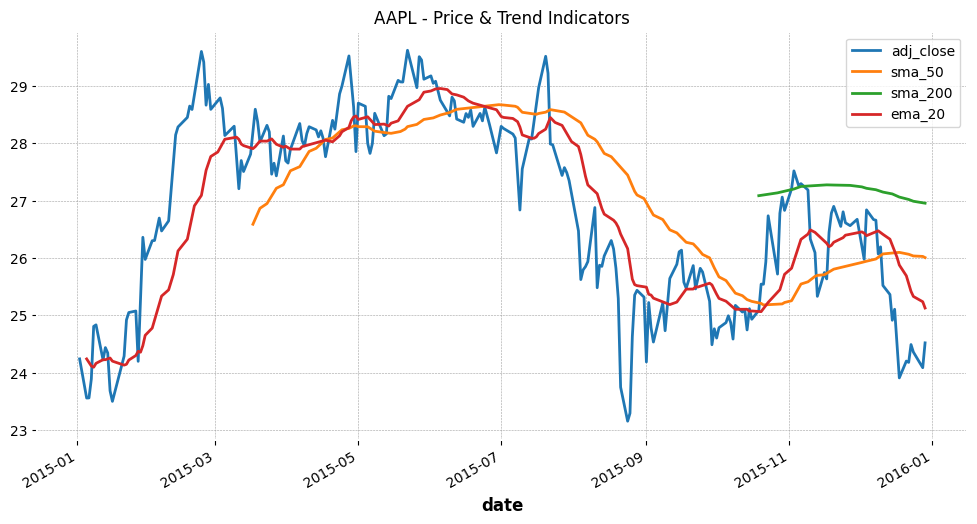

In [6]:
cols = [
    "adj_close",
    "sma_50",
    "sma_200",
    "ema_20",
]

aapl = df[df["ticker"]=="AAPL"].set_index("date")
aapl[cols].iloc[:250].plot(figsize=(12,6))
plt.title("AAPL - Price & Trend Indicators")
plt.show()

We move the the Momentum indicators, where we need to make sure that
- RSI is correctly computed, with values between 0 and 100
- MACD lines are correctly computed, with MACD line oscillating around the Signal line and both lines oscillating around zero.

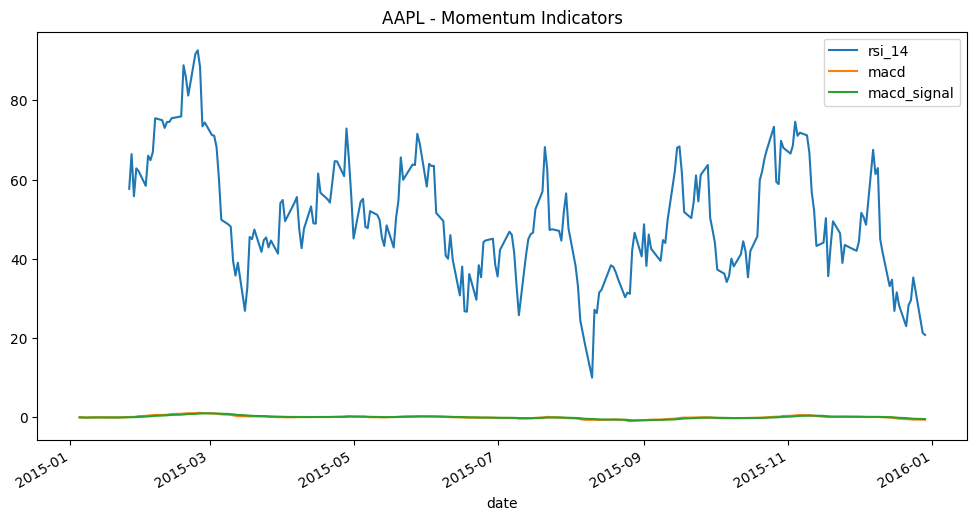

In [22]:
cols = [
    "rsi_14",
    "macd",
    "macd_signal",
]
aapl[cols].iloc[:250].plot(figsize=(12,6))
plt.title("AAPL - Momentum Indicators")
plt.show()

Finally, we check that volatility indicators are correctly computed. We only have volatility (20-day std) in the dataset for now.


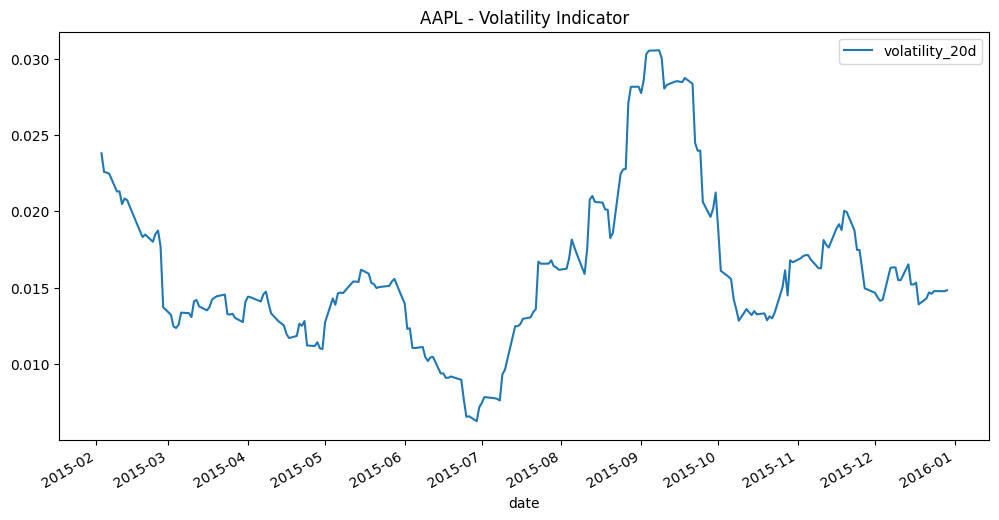

In [29]:
cols = [
    "volatility_20d",
]
aapl[cols].iloc[:250].plot(figsize=(12,6))
plt.title("AAPL - Volatility Indicator")
plt.show()

As everything seems correct, we can move on to the next data checks

## Fundamental Data

First of all, we have to check that features change quarterly as expected. We also need to ensure that the fast forward fill is working properly.
As we considered a lag of 60 days from the end of the quarter to the publishment of the fundamental data (financials, balance and cash flow), we end up with 5 time intervals:
- 2024-11-29 → 2025-02-28	- `value 1`
- 2025-03-01 → 2025-05-29	- `value 2`
- 2025-05-30 → 2025-08-28	- `value 3`
- 2025-08-29 → 2025-11-28	- `value 4`
- 2025-11-29 → today -	`value 5` \
We need to make sure that this is true, by selecting random dates between those intervals and check that the value of a date is the same of another date that belongs to the same interval

In [60]:
# First of all, we have to check that features change quarterly or monthly as expected.
# We also need to ensure that the fast forward fill is working properly.
fund_cols = [
    "net_margin",
    "roe",
    "debt_to_equity"
]

date_cols = ["2024-11-27", "2024-11-29", "2024-12-31", "2025-01-02", "2025-02-18", "2025-03-31", "2025-04-01", "2025-05-15", "2025-06-30", "2025-07-01", "2025-08-15", "2025-09-30", "2025-10-01", "2025-11-14", "2025-12-31", "2026-01-02"]
aapl_fund = df[df["ticker"]=="AAPL"].set_index("date")[fund_cols].loc[date_cols]
aapl_fund



,net_margin,roe,debt_to_equity
date,,,
2024-11-27,NaN,NaN,NaN
2024-11-29,0.155230,0.258753,1.872327
2024-12-31,0.155230,0.258753,1.872327
2025-01-02,0.155230,0.258753,1.872327
2025-02-18,0.155230,0.258753,1.872327
2025-03-31,0.292277,0.544204,1.449999
2025-04-01,0.292277,0.544204,1.449999
2025-05-15,0.292277,0.544204,1.449999
2025-06-30,0.259860,0.370980,1.469938


As we can see, it works perfectly. We now have to make sure that those features haven't been replicated wrong. For this, we check the ROE for every ticker, expecting different values

In [140]:
df.groupby("ticker")["roe"].mean().sort_values()

ticker
TSLA     0.020146
XOM      0.028459
AMZN     0.059570
JNJ      0.073830
MSFT     0.080705
GOOGL    0.086241
META     0.089800
KO       0.108201
NVDA     0.264715
AAPL     0.381687
Name: roe, dtype: float64

## Macro Data

We need to check that macroeconomic features are shifted properly:
- `GDP` is updated every 3 months, with a 60 days shift
- `CPIAUCSL` is updated every month, with a 15 days shift
- `FEDFUNDS` is updated every month, with no shift \

In [128]:

date_cols = ["2015-01-02","2015-02-02", "2015-03-03", "2015-04-01", "2015-05-01", "2015-06-01", "2015-07-01", "2015-08-03", "2015-09-01", "2015-10-01", "2015-11-02", "2015-12-01"]

aapl_macro_gdp = df[df["ticker"]=="AAPL"].set_index("date")['GDP'].loc[date_cols]
print(aapl_macro_gdp)

date
2015-01-02          NaN
2015-02-02          NaN
2015-03-03    18063.529
2015-04-01    18063.529
2015-05-01    18063.529
2015-06-01    18279.784
2015-07-01    18279.784
2015-08-03    18279.784
2015-09-01    18401.626
2015-10-01    18401.626
2015-11-02    18401.626
2015-12-01    18435.137
Name: GDP, dtype: float64


In [129]:
aapl_macro_cpi = df[df["ticker"]=="AAPL"].set_index("date")['CPIAUCSL'].loc[date_cols]
print(aapl_macro_cpi)

date
2015-01-02        NaN
2015-02-02    234.747
2015-03-03    235.342
2015-04-01    235.976
2015-05-01    236.222
2015-06-01    237.001
2015-07-01    237.657
2015-08-03    238.034
2015-09-01    238.033
2015-10-01    237.498
2015-11-02    237.733
2015-12-01    238.017
Name: CPIAUCSL, dtype: float64


In [130]:
aapl_macro_fed = df[df["ticker"]=="AAPL"].set_index("date")['FEDFUNDS'].loc[date_cols]
print(aapl_macro_fed)

date
2015-01-02    0.11
2015-02-02    0.11
2015-03-03    0.11
2015-04-01    0.12
2015-05-01    0.12
2015-06-01    0.13
2015-07-01    0.13
2015-08-03    0.14
2015-09-01    0.14
2015-10-01    0.12
2015-11-02    0.12
2015-12-01    0.24
Name: FEDFUNDS, dtype: float64


We check the macro data graphics to see if the result is the expected:

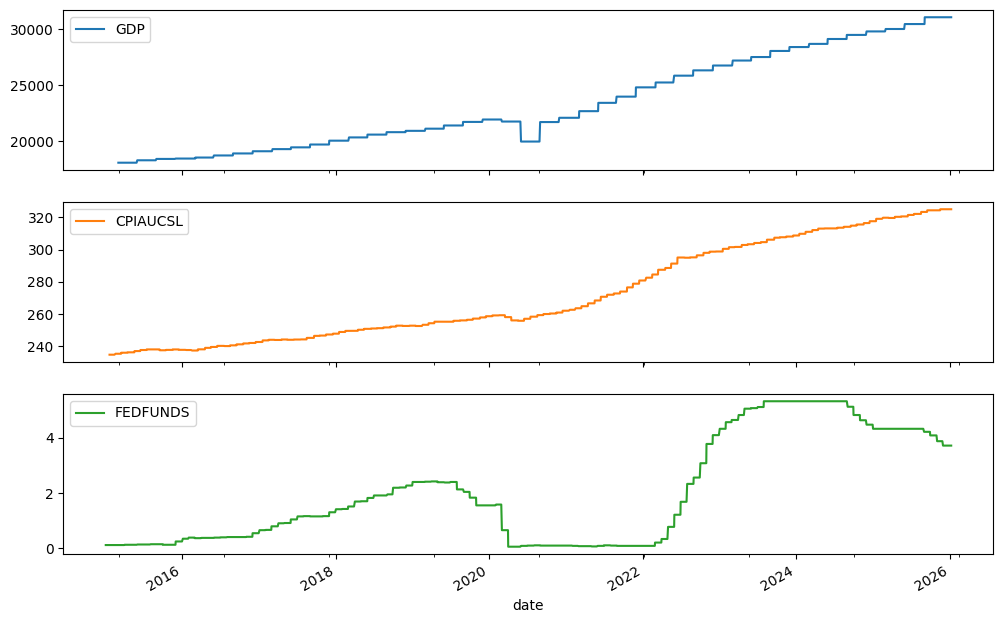

In [84]:
macro_cols = ["GDP", "CPIAUCSL", "FEDFUNDS"]

aapl[macro_cols].plot(subplots=True, figsize=(12,8))
plt.show()

## Missing Values and Duplicateds

We start by checking the missing value of the full database, expecting a very high percentage in fundamental features, as we only have data for them from 29th November 2024.

In [77]:
df.isna().mean().sort_values(ascending=False).head(20)

revenue_growth_yoy     0.977958
fcf_growth_yoy         0.977958
earnings_growth_yoy    0.977958
fcf_margin             0.900433
roa                    0.900433
current_ratio          0.900433
debt_to_equity         0.900433
roe                    0.900433
asset_turnover         0.900433
ebitda_margin          0.900433
operating_margin       0.900433
net_margin             0.900433
sma_200                0.072150
sma_50                 0.018038
price_sma_50           0.018038
GDP                    0.014430
ret_21d                0.007937
volatility_20d         0.007576
rsi_14                 0.005411
CPIAUCSL               0.003968
dtype: float64

Now we consider the database only from 29th November 2024 onward, hoping for the fundamental features missing value percentage to decrease drastically.

In [78]:
df_recent = df[df["date"] >= "2024-11-29"]
df_recent.isna().mean().sort_values(ascending=False).head(20)

earnings_growth_yoy    0.780216
revenue_growth_yoy     0.780216
fcf_growth_yoy         0.780216
operating_margin       0.007194
ebitda_margin          0.007194
asset_turnover         0.007194
roe                    0.007194
roa                    0.007194
fcf_margin             0.007194
net_margin             0.007194
debt_to_equity         0.007194
current_ratio          0.007194
open                   0.000000
GDP                    0.000000
CPIAUCSL               0.000000
FEDFUNDS               0.000000
date                   0.000000
ret_21d                0.000000
ret_5d                 0.000000
ret_1d                 0.000000
dtype: float64

As expected, most of the fundamental features have now less than 1% of missing values. On the other hand, yoy features have more than 77% of missing values.

Finally, we check that there are no duplicated tandems of date and ticker

In [64]:
df.duplicated(subset=["date", "ticker"]).sum()

np.int64(0)